In [57]:
import pandas as pd
import numpy as np

In [58]:
df=pd.read_csv(r"E:\Downloads\Excel_sheets\Churn_Modelling.csv")

In [59]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [60]:
df.shape

(10000, 14)

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df['Exited'].value_counts()  # imbalanced dataset

Exited
0    7963
1    2037
Name: count, dtype: int64

In [64]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [65]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [66]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [67]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [68]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)

In [69]:
X=df.drop(columns=['Exited'])
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [70]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9254,686,32,6,0.00,2,1,1,179093.26,0,0,1
1561,632,42,4,119624.60,2,1,1,195978.86,1,0,1
1670,559,24,3,114739.92,1,1,0,85891.02,0,1,1
6087,561,27,9,135637.00,1,1,0,153080.40,0,0,0
6669,517,56,9,142147.32,1,0,0,39488.04,0,0,1


In [71]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [72]:
import tensorflow

In [73]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [85]:
model=Sequential()
#model.add(Dense(3,activation='sigmoid',input_dim=11))
#model.add(Dense(1,activation='sigmoid'))
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

C:\Users\Rishikesh Reddy\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [94]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8672 - loss: 0.3199 - val_accuracy: 0.8587 - val_loss: 0.3411
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8670 - loss: 0.3197 - val_accuracy: 0.8575 - val_loss: 0.3403
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8689 - loss: 0.3197 - val_accuracy: 0.8550 - val_loss: 0.3409
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8694 - loss: 0.3193 - val_accuracy: 0.8550 - val_loss: 0.3421
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8705 - loss: 0.3195 - val_accuracy: 0.8594 - val_loss: 0.3413
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8694 - loss: 0.3191 - val_accuracy: 0.8569 - val_loss: 0.3413
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8687 - loss: 0.3196 - val_accuracy: 0.8606 - val_loss: 0.3415
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8683 - loss: 0.3191 - val_accu

In [89]:
model.layers[0].get_weights()

[array([[-5.68101645e-01, -1.06781222e-01, -2.82374322e-02,
          3.40807468e-01,  9.62700248e-02, -1.34063605e-02,
         -7.80761018e-02, -1.02111557e-03, -1.11103423e-01,
         -1.50411114e-01, -6.72367066e-02],
        [-3.57353836e-01,  8.03109229e-01, -2.29622141e-01,
         -4.99478042e-01,  2.52894729e-01, -6.67126775e-01,
          7.09977627e-01,  6.53285757e-02, -4.69844073e-01,
          4.57894504e-01, -4.80811507e-01],
        [ 2.44831696e-01,  4.15504053e-02,  2.22825240e-02,
         -1.27410963e-01,  1.42119471e-02, -1.10023871e-01,
         -1.47641957e-01,  1.03079170e-01, -2.37179980e-01,
          1.78043861e-02,  4.20583598e-02],
        [ 5.06045401e-01, -2.83698946e-01,  6.71350444e-03,
          1.11534134e-01, -4.72645342e-01, -6.20934404e-02,
         -9.72258523e-02, -6.16320312e-01, -8.88270140e-01,
          3.12251568e-01,  4.85681891e-02],
        [-3.27879757e-01,  6.60044253e-02,  9.82404709e-01,
         -3.30104351e-01,  2.41977349e-01,  

In [90]:
model.layers[1].get_weights()

[array([[-2.4215506e-01, -3.3074087e-01, -6.9683111e-01, -5.1572126e-01,
          2.8187245e-01, -2.8298199e-01,  1.3559428e-01,  2.3552452e-01,
          1.3830508e-01, -3.0895284e-01,  4.2795759e-01],
        [-4.8433733e-01, -4.9746504e-01,  9.0736121e-01,  1.3236678e-01,
          2.3820575e-01,  5.6197947e-01,  7.5616610e-01, -5.2167758e-02,
         -4.9666175e-01,  5.1517463e-01,  3.9996466e-01],
        [ 4.7090343e-01,  6.4803332e-01, -7.1147799e-01,  3.6547396e-02,
          2.3676203e-01,  1.3812441e-01,  4.5535830e-01, -7.0343155e-01,
          4.7012103e-01, -1.4977106e-02, -4.3288836e-01],
        [-4.6420363e-01, -4.0939301e-01, -7.5839722e-01, -7.3935583e-02,
         -4.4727910e-01,  8.2041912e-02,  1.7840205e-01, -6.9018885e-02,
          4.6704629e-01,  1.8048818e-01,  3.2302797e-01],
        [ 2.6907289e-01,  6.3597143e-02,  1.2019342e-01,  9.3398981e-02,
          6.6925341e-01,  3.0387774e-01,  2.3044109e-01, -1.9082523e-04,
          6.5797144e-03,  5.0354010e-0

In [91]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step


In [92]:
y_pred=np.where(y_log>0.5,1,0) # the thresold is fixed by using ROC and AUC curves

In [93]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.865

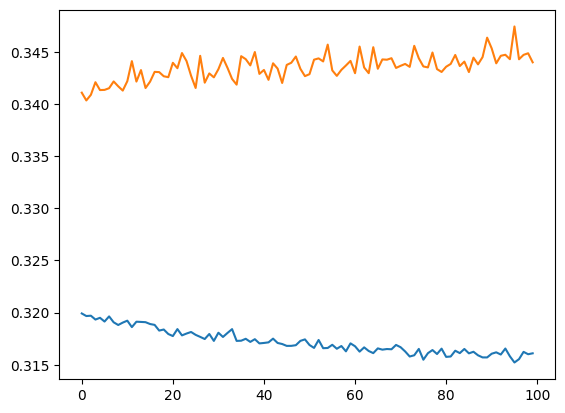

In [96]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

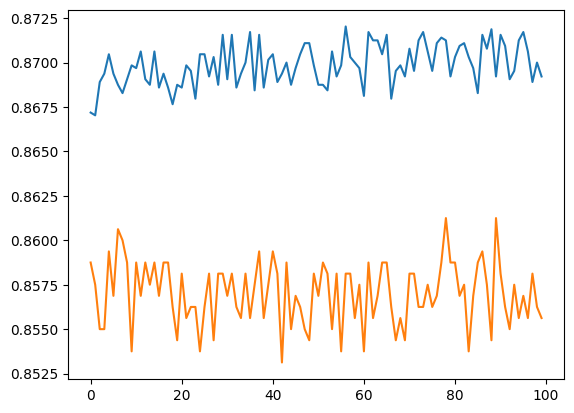

In [97]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])